# <p><center style="font-family:newtimeroman;font-size:180%;">Alzheimers Dataset 3 Class ADNI Detection and Quality Evaluation Using Image Analysis </center></p>
### Table of contents:

* [Import Libraries](#1)
* [Read Data](#2)
* [Visualization Of Dataset](#3)
* [Data Augmentation](#4)
* [CNN Model](#10)
* [Evaluate The Model](#11)

**<a id="1"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Import Libraries </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [9]:
import os 
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow import keras 
from keras.callbacks import EarlyStopping,ModelCheckpoint
import tensorflow as tf
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from tqdm import tqdm
from imblearn.over_sampling import SMOTE

**<a id="2"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Read Data </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [43]:
images = []
labels = []
for subfolder in tqdm(os.listdir('/Users/yashbanerjee/Downloads/ADNI_1.5T_axial-5to5_ants_flirt_B180n350_9440')):
    subfolder_path = os.path.join('/Users/yashbanerjee/Downloads/ADNI_1.5T_axial-5to5_ants_flirt_B180n350_9440', subfolder)
    print(subfolder_path)
    for image_filename in os.listdir(subfolder_path):
        image_path = os.path.join(subfolder_path, image_filename)
        images.append(image_path)
        labels.append(subfolder)
df = pd.DataFrame({'image': images, 'label': labels})
df

100%|█████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 55.50it/s]

/Users/yashbanerjee/Downloads/ADNI_1.5T_axial-5to5_ants_flirt_B180n350_9440/AD
/Users/yashbanerjee/Downloads/ADNI_1.5T_axial-5to5_ants_flirt_B180n350_9440/CN
/Users/yashbanerjee/Downloads/ADNI_1.5T_axial-5to5_ants_flirt_B180n350_9440/MCI


,image,label
0,/Users/yashbanerjee/Downloads/ADNI_1.5T_axial-...,AD
1,/Users/yashbanerjee/Downloads/ADNI_1.5T_axial-...,AD
2,/Users/yashbanerjee/Downloads/ADNI_1.5T_axial-...,AD
3,/Users/yashbanerjee/Downloads/ADNI_1.5T_axial-...,AD
4,/Users/yashbanerjee/Downloads/ADNI_1.5T_axial-...,AD
...,...,...
9433,/Users/yashbanerjee/Downloads/ADNI_1.5T_axial-...,MCI
9434,/Users/yashbanerjee/Downloads/ADNI_1.5T_axial-...,MCI
9435,/Users/yashbanerjee/Downloads/ADNI_1.5T_axial-...,MCI
9436,/Users/yashbanerjee/Downloads/ADNI_1.5T_axial-...,MCI


**<a id="3"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Visualization of Dataset </p>
<a class="btn" href="#home">Tabel of Contents</a>

/var/folders/85/v12n02wd6vqbmmg35c8xd7hc0000gp/T/ipykernel_50561/4095864232.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df.label,palette='Set1')


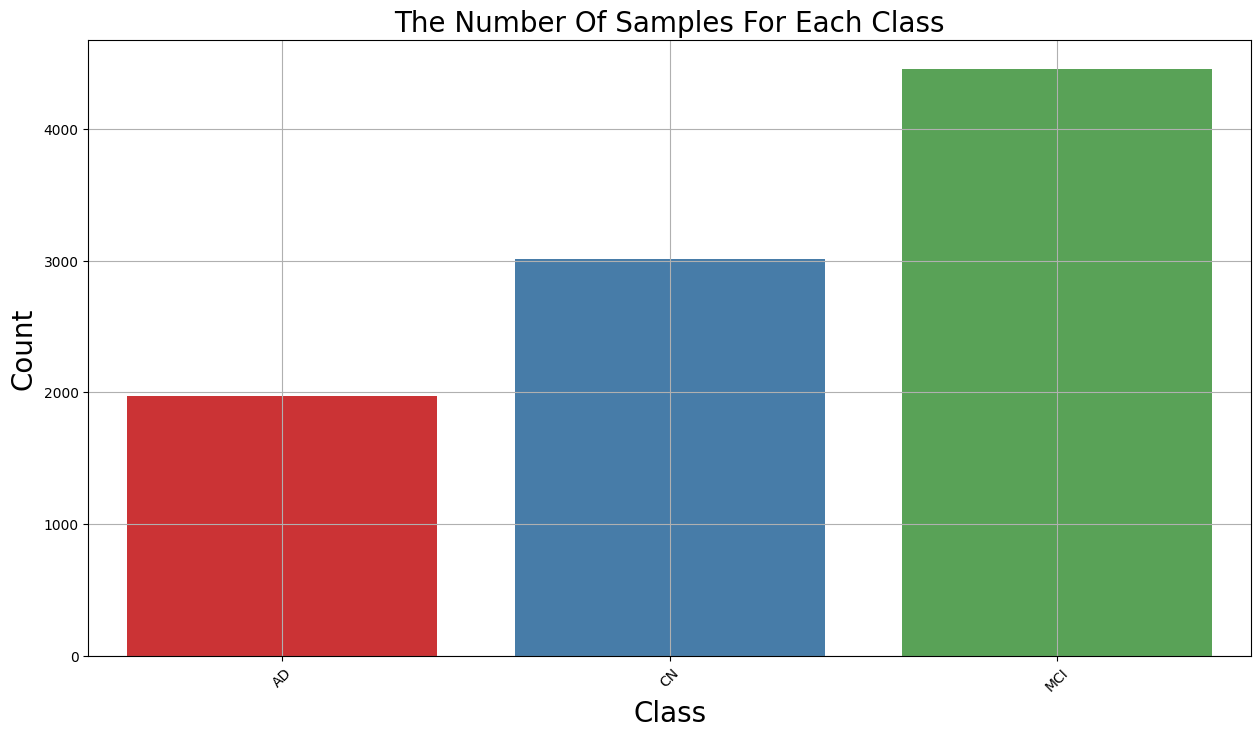

In [44]:
plt.figure(figsize=(15,8))
ax = sns.countplot(x=df.label,palette='Set1')
ax.set_xlabel("Class",fontsize=20)
ax.set_ylabel("Count",fontsize=20)
plt.title('The Number Of Samples For Each Class',fontsize=20)
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

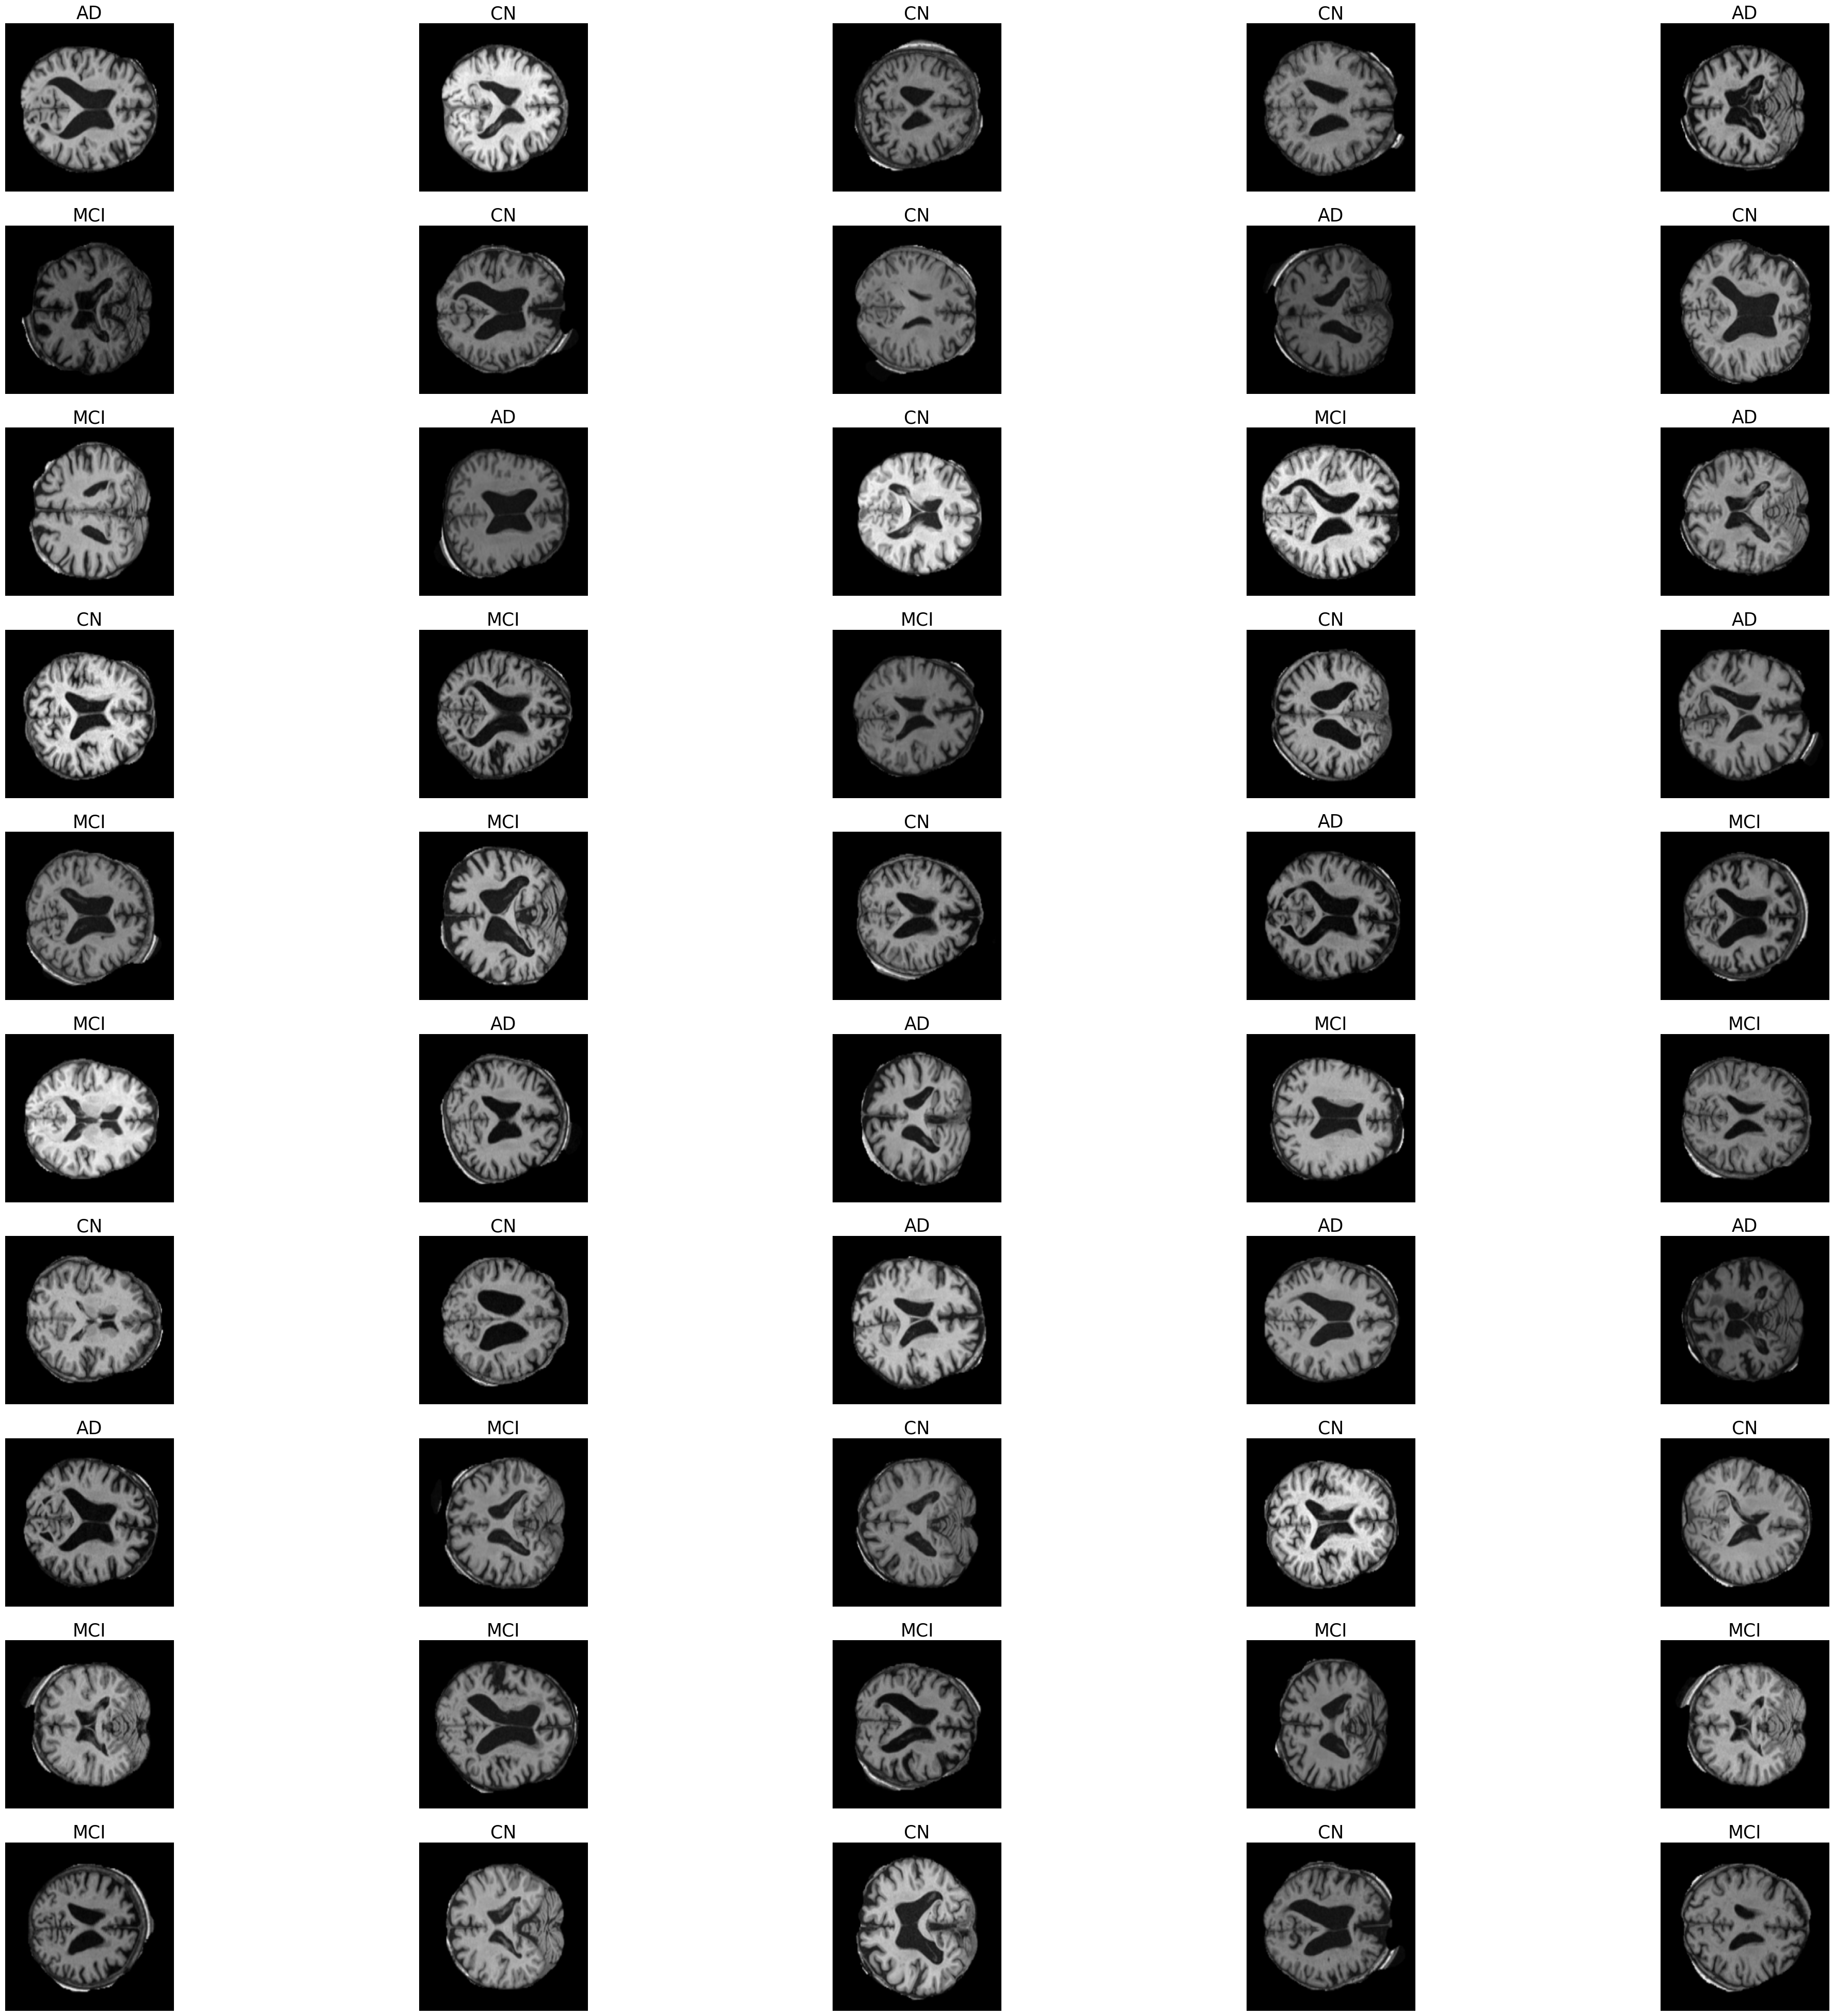

In [45]:
plt.figure(figsize=(50,50))
for n,i in enumerate(np.random.randint(0,len(df),50)):
    plt.subplot(10,5,n+1)
    img=cv2.imread(df.image[i])
    img=cv2.resize(img,(224,224))
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis('off')
    plt.title(df.label[i],fontsize=25)

<a id="4"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px"> Data Augmentation </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [46]:
Size=(176,176)
work_dr = ImageDataGenerator(
    rescale = 1./255
)
train_data_gen = work_dr.flow_from_dataframe(df,x_col='image',y_col='label', target_size=Size, batch_size=6500, shuffle=False)

Found 9438 validated image filenames belonging to 3 classes.


In [47]:
train_data, train_labels = next(train_data_gen)

In [48]:
class_num=list(train_data_gen.class_indices.keys())
class_num

['AD', 'CN', 'MCI']

In [49]:
#sm = SMOTE(random_state=42)
#train_data, train_labels = sm.fit_resample(train_data.reshape(-1, 176 * 176 * 3), train_labels)
train_data = train_data.reshape(-1, 176,176, 3)
print(train_data.shape, train_labels.shape)

(6500, 176, 176, 3) (6500, 3)


/var/folders/85/v12n02wd6vqbmmg35c8xd7hc0000gp/T/ipykernel_50561/1034950569.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=labels,palette='Set1')


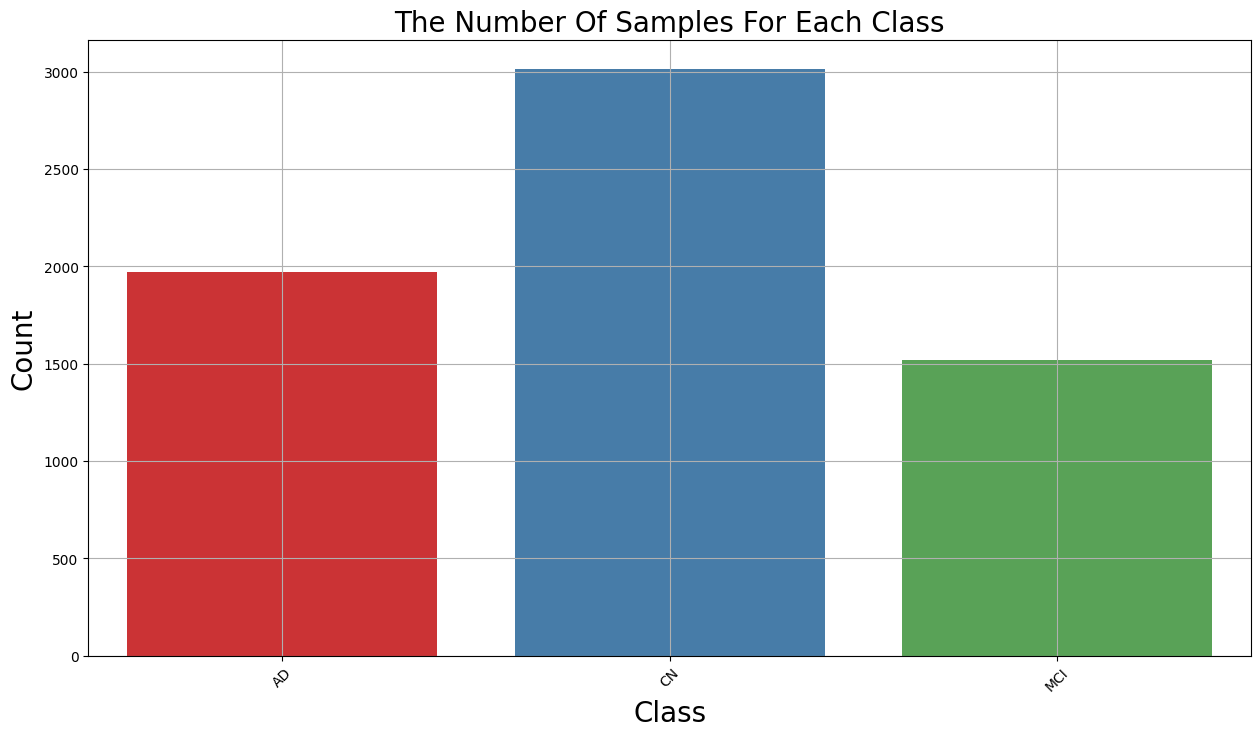

In [50]:
labels=[class_num[i] for i in np.argmax(train_labels,axis=1) ]
plt.figure(figsize=(15,8))
ax = sns.countplot(x=labels,palette='Set1')
ax.set_xlabel("Class",fontsize=20)
ax.set_ylabel("Count",fontsize=20)
plt.title('The Number Of Samples For Each Class',fontsize=20)
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [51]:
X_train, X_test1, y_train, y_test1 = train_test_split(train_data,train_labels, test_size=0.3, random_state=42,shuffle=True,stratify=train_labels)
X_val, X_test, y_val, y_test = train_test_split(X_test1,y_test1, test_size=0.5, random_state=42,shuffle=True,stratify=y_test1)
print('X_train shape is ' , X_train.shape)
print('X_test shape is ' , X_test.shape)
print('X_val shape is ' , X_val.shape)
print('y_train shape is ' , y_train.shape)
print('y_test shape is ' , y_test.shape)
print('y_val shape is ' , y_val.shape)

X_train shape is  (4550, 176, 176, 3)
X_test shape is  (975, 176, 176, 3)
X_val shape is  (975, 176, 176, 3)
y_train shape is  (4550, 3)
y_test shape is  (975, 3)
y_val shape is  (975, 3)


<a id="10"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">CNN Modeling </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [52]:
model=keras.models.Sequential()
model.add(keras.layers.Conv2D(32,kernel_size=(3,3),strides=2,padding='same',activation='relu',input_shape=(176,176,3)))
model.add(keras.layers.MaxPool2D(pool_size=(2,2),strides=2,padding='same'))
model.add(keras.layers.Conv2D(64,kernel_size=(3,3),strides=2,activation='relu',padding='same'))
model.add(keras.layers.MaxPool2D((2,2),2,padding='same'))
model.add(keras.layers.Conv2D(128,kernel_size=(3,3),strides=2,activation='relu',padding='same'))
model.add(keras.layers.MaxPool2D((2,2),2,padding='same'))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(1024,activation='relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(3,activation='softmax'))
model.summary()

/Users/yashbanerjee/Pythonprojects/MedMamba/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 88, 88, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 44, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 22, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     1,180,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │         3,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,276,995 (4.87 MB)

 Trainable params: 1,276,995 (4.87 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
tf.keras.utils.plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True,show_dtype=True,dpi=120)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [54]:
checkpoint_cb =ModelCheckpoint("CNN_model.h5", save_best_only=True)
early_stopping_cb =EarlyStopping(patience=10, restore_best_weights=True)
model.compile(optimizer ='adam', loss='categorical_crossentropy', metrics=['accuracy'])
hist = model.fit(X_train,y_train, epochs=50, validation_data=(X_val,y_val), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/50
139/143 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4806 - loss: 1.0484

143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4813 - loss: 1.0404 - val_accuracy: 0.5067 - val_loss: 0.9781
Epoch 2/50
138/143 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6065 - loss: 0.8916

143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6433 - loss: 0.8239 - val_accuracy: 0.7477 - val_loss: 0.6537
Epoch 3/50
138/143 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7879 - loss: 0.5492

143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8079 - loss: 0.4981 - val_accuracy: 0.8297 - val_loss: 0.4257
Epoch 4/50
138/143 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8795 - loss: 0.3146

143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8971 - loss: 0.2831 - val_accuracy: 0.9149 - val_loss: 0.2562
Epoch 5/50
138/143 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9486 - loss: 0.1623

143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9541 - loss: 0.1407 - val_accuracy: 0.9497 - val_loss: 0.1641
Epoch 6/50
138/143 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9794 - loss: 0.0737

143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9741 - loss: 0.0835 - val_accuracy: 0.9415 - val_loss: 0.1595
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9848 - loss: 0.0424 - val_accuracy: 0.9467 - val_loss: 0.1767
Epoch 8/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9842 - loss: 0.0461 - val_accuracy: 0.9487 - val_loss: 0.1653
Epoch 9/50
138/143 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9916 - loss: 0.0226

143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9949 - loss: 0.0158 - val_accuracy: 0.9600 - val_loss: 0.1403
Epoch 10/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9930 - loss: 0.0208 - val_accuracy: 0.8954 - val_loss: 0.4276
Epoch 11/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9798 - loss: 0.0569 - val_accuracy: 0.9405 - val_loss: 0.2107
Epoch 12/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9901 - loss: 0.0296 - val_accuracy: 0.9528 - val_loss: 0.1556
Epoch 13/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9960 - loss: 0.0112 - val_accuracy: 0.9692 - val_loss: 0.1601
Epoch 14/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9974 - loss: 0.0102 - val_accuracy: 0.9487 - val_loss: 0.2468
Epoch 15/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9989 - loss: 0.0039 - val_accuracy: 0.9723 - val_loss: 0.1453
Epoch 16/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9993 - loss: 0.0018 - val_accuracy

<a id="11"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px"> Evaluate The Model  </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [55]:
hist_=pd.DataFrame(hist.history)
hist_

,accuracy,loss,val_accuracy,val_loss
0,0.481319,1.040387,0.506667,0.978093
1,0.643297,0.823872,0.747692,0.653721
2,0.807912,0.498077,0.829744,0.425679
3,0.897143,0.283145,0.914872,0.256156
4,0.954066,0.140739,0.949744,0.164131
5,0.974066,0.083522,0.941538,0.159497
6,0.984835,0.042352,0.946667,0.176661
7,0.984176,0.046070,0.948718,0.165277
8,0.994945,0.015829,0.960000,0.140312
9,0.992967,0.020819,0.895385,0.427578


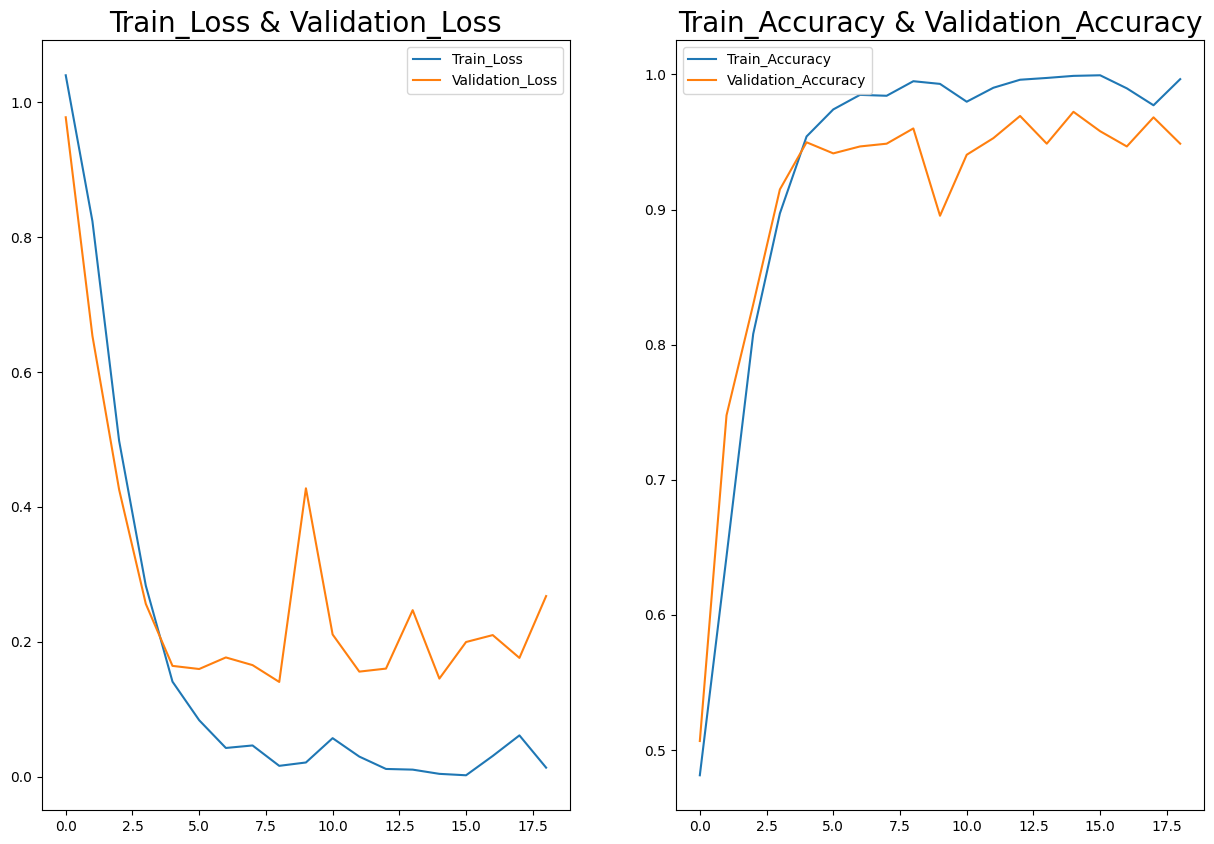

In [56]:
plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
plt.plot(hist_['loss'],label='Train_Loss')
plt.plot(hist_['val_loss'],label='Validation_Loss')
plt.title('Train_Loss & Validation_Loss',fontsize=20)
plt.legend()
plt.subplot(1,2,2)
plt.plot(hist_['accuracy'],label='Train_Accuracy')
plt.plot(hist_['val_accuracy'],label='Validation_Accuracy')
plt.title('Train_Accuracy & Validation_Accuracy',fontsize=20)
plt.legend()
plt.show()

In [57]:
score, acc= model.evaluate(X_test,y_test)
print('Test Loss =', score)
print('Test Accuracy =', acc)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9641 - loss: 0.1455
Test Loss = 0.14550597965717316
Test Accuracy = 0.964102566242218


In [58]:
predictions = model.predict(X_test)
y_pred = np.argmax(predictions,axis=1)
y_test_ = np.argmax(y_test,axis=1)
df = pd.DataFrame({'Actual': y_test_, 'Prediction': y_pred})
df

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


,Actual,Prediction
0,0,0
1,1,1
2,2,2
3,0,0
4,0,0
...,...,...
970,1,2
971,2,2
972,0,0
973,0,0


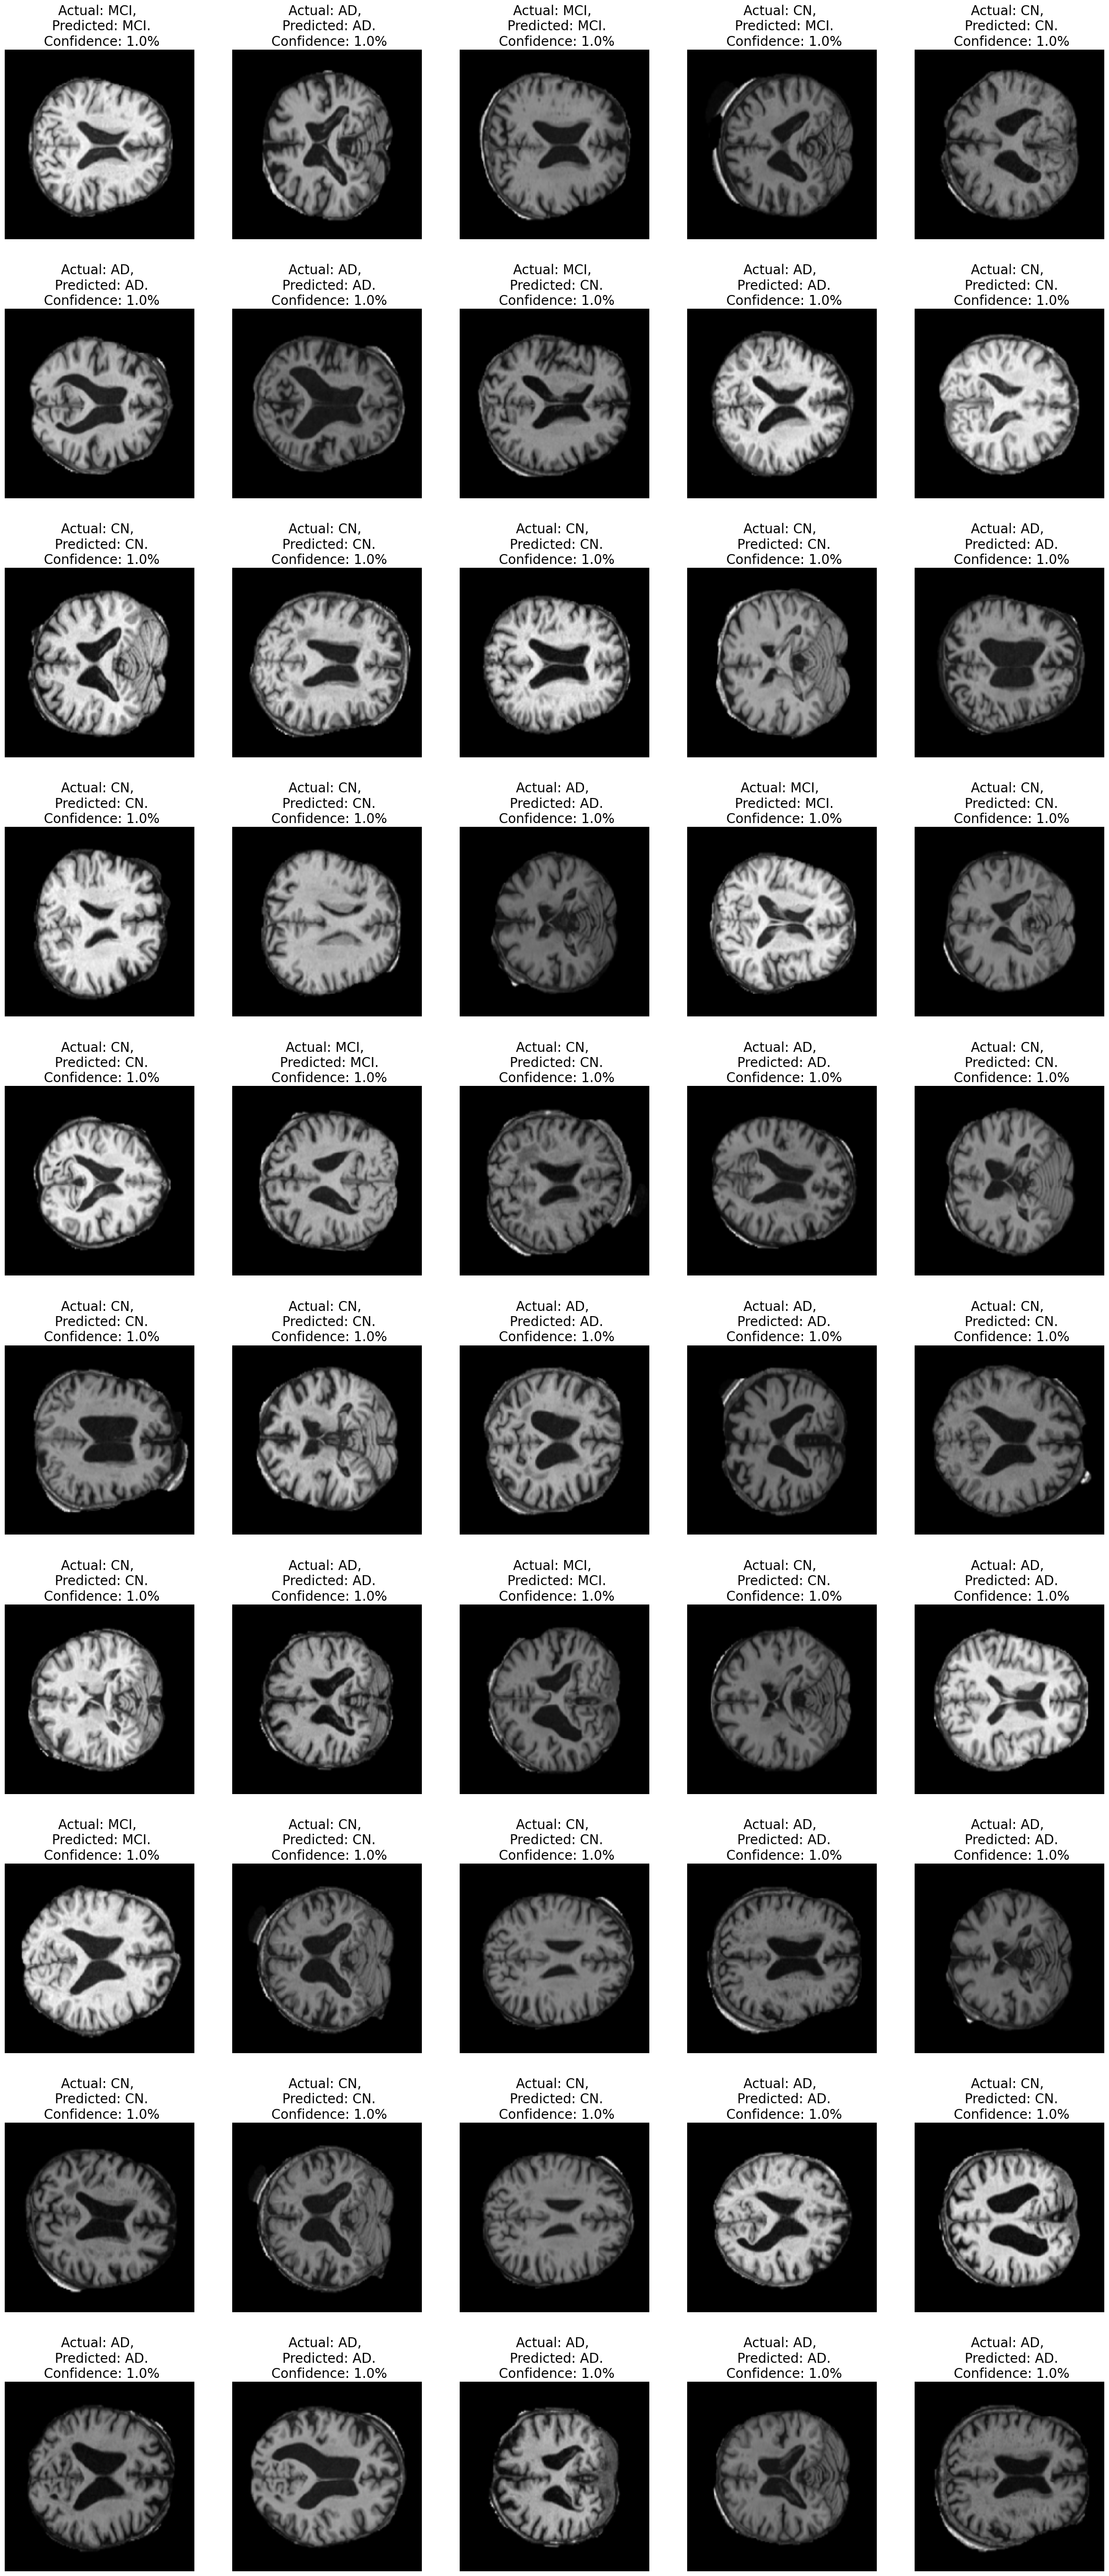

In [59]:
plt.figure(figsize=(30,70))
for n,i in enumerate(np.random.randint(0,len(X_test),50)):
    plt.subplot(10,5,n+1)
    plt.imshow(X_test[i])
    plt.axis('off')
    plt.title(f"Actual: {class_num[y_test_[i]]}, \n Predicted: {class_num[y_pred[i]]}.\n Confidence: {round(predictions[i][np.argmax(predictions[i])],0)}%",fontsize=20)

array([[286,   6,   3],
       [  1, 438,  13],
       [  1,  11, 216]])

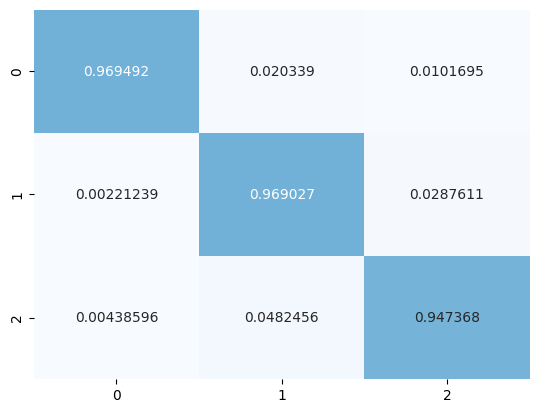

In [60]:
CM = confusion_matrix(y_test_,y_pred)
CM_percent = CM.astype('float') / CM.sum(axis=1)[:, np.newaxis]
sns.heatmap(CM_percent,fmt='g',center = True,cbar=False,annot=True,cmap='Blues')
CM

In [61]:
ClassificationReport = classification_report(y_test_,y_pred)
print('Classification Report is : ', ClassificationReport )

Classification Report is :                precision    recall  f1-score   support

           0       0.99      0.97      0.98       295
           1       0.96      0.97      0.97       452
           2       0.93      0.95      0.94       228

    accuracy                           0.96       975
   macro avg       0.96      0.96      0.96       975
weighted avg       0.96      0.96      0.96       975



In [62]:
TEST_DATASET = '/Users/yashbanerjee/Downloads/ADNI_1.5T_axial-2to2_ants_flirt_N4_B180_lastof5'

In [63]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    TEST_DATASET,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False # Keep false for accurate evaluation
)
imagesTest = []
labelsTest = []
for subfolder in tqdm(os.listdir(TEST_DATASET)):
    subfolder_path = os.path.join(TEST_DATASET, subfolder)
    print(subfolder_path)
    for image_filename in os.listdir(subfolder_path):
        image_path = os.path.join(subfolder_path, image_filename)
        imagesTest.append(image_path)
        labelsTest.append(subfolder)
dfTest = pd.DataFrame({'image': imagesTest, 'label': labelsTest})



Found 850 images belonging to 3 classes.


100%|███████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 1875.25it/s]

/Users/yashbanerjee/Downloads/ADNI_1.5T_axial-2to2_ants_flirt_N4_B180_lastof5/AD
/Users/yashbanerjee/Downloads/ADNI_1.5T_axial-2to2_ants_flirt_N4_B180_lastof5/CN
/Users/yashbanerjee/Downloads/ADNI_1.5T_axial-2to2_ants_flirt_N4_B180_lastof5/MCI


In [64]:
Size=(176,176)
work_drTest = ImageDataGenerator(
    rescale = 1./255
)
test_data_gen_1 = work_drTest.flow_from_dataframe(dfTest,x_col='image',y_col='label', target_size=Size, batch_size=6500, shuffle=False)

Found 850 validated image filenames belonging to 3 classes.


In [65]:
test_data, test_labels = next(test_data_gen_1)
#smTest = SMOTE(random_state=42)
#test_data, test_labels = sm.fit_resample(test_data.reshape(-1, 176 * 176 * 3), test_labels)
test_data = test_data.reshape(-1, 176,176, 3)
print(test_data.shape, test_labels.shape)

(850, 176, 176, 3) (850, 3)


In [66]:
score, acc= model.evaluate(test_data,test_labels)
print('Test Loss =', score)
print('Test Accuracy =', acc)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4329 - loss: 4.1471
Test Loss = 4.147116661071777
Test Accuracy = 0.43294116854667664
